# PS-S06E07: Model Stacking

This notebook trains a meta-model (`RidgeClassifierCV`) using the out-of-fold (OOF) predictions of **7 base models**:
1. **CatBoost** (standard)
2. **LightGBM** (standard)
3. **XGBoost** (standard)
4. **Random Forest** (standard)
5. **NN Tabular ResNet** (standard)
6. **LightGBM Pseudo** (trained on pseudo-labeled test set data)
7. **XGBoost Pseudo** (trained on pseudo-labeled test set data)

Integrating both standard models and pseudo-labeled models allows the meta-model to learn diverse decision boundaries on the validation set. We use `RidgeClassifierCV` as it is highly robust to collinear probabilities, and apply **bias calibration** to the stacked decision function.


This notebook tackles the [**Playground Series – Season 6, Episode 7: Predicting Student Health Risk**](https://www.kaggle.com/competitions/playground-series-s6e7), a competition focused on predicting a class label (`at-risk`, `unhealthy`, `fit`) for the `class` target, based on features describing the position, light intensity for various spectrums, and other features of the observation.

## Ensemble Strategy: Stacking with a Logistic Meta-Model

Blending (weighted averaging) can fail when one model is dominant or when models are highly correlated. Stacking treats ensembling as a supervised learning problem: we train a small meta-model to combine base model probabilities.

A practical advantage is that a weaker model can still help if it is *differently wrong*—the meta-model can learn when to trust it.


## Install Needed Packages

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_predict, StratifiedKFold

from ps_s06e07_experiment_setup import ExperimentSetup
from ps_s06e07_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
setup = ExperimentSetup()

seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'health_condition'

Random seed set to: 10301
Warnings suppressed.


In [3]:
# Load ground truth labels
training_df = setup.read_dataset('training')

# Encode target labels
target_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
y_true = training_df[TARGET].map(target_mapping).astype(int)

TRAINING DATASET

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy           5.220      70.600 25.660   
1   1          at-risk           5.530      71.300 25.840   
2   2        unhealthy           5.290      75.400 24.540   
3   3        unhealthy           4.700      77.200 23.130   
4   4          at-risk           7.230      73.400 28.440   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0            2,174.000   1,326.000             19.800         1.860       veg   
1            1,966.000   9,891.000             49.900         1.260   non-veg   
2            2,688.000  14,216.000             38.100         1.600       veg   
3            2,630.000   7,174.000             59.900         2.020       veg   
4            2,560.000   6,584.000             46.000         2.250       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  \
0         high       average               seden

In [4]:
submission_df = setup.read_dataset('submission')

## Loading OOF and Test Probabilities

We load the out-of-fold (OOF) and test-set **probabilities** generated by individual model notebooks.

Expected file naming:
- `*_oof_probs.csv` contains columns: `id`, one probability column (e.g. `prob_xgb`), and optionally `target`
- `*_test_probs.csv` contains columns: `id` and one probability column

All files should share the same `id` values as the competition datasets.


In [5]:
oof_files = []
test_files = []

# Local convention: predictions stored under predictions/s06e07/
# Kaggle convention: mount dataset input that contains predictions/
if setup.running_in_kaggle():
    pred_dir = '/kaggle/input/notebooks/stephentarter/ps-s06e07-*/predictions'
else:
    pred_dir = 'predictions'

EXCLUDE_PREFIXES = ('blending', 'stacking')

def _is_base_model_file(path):
    name = os.path.basename(path)
    return not name.startswith(EXCLUDE_PREFIXES)

oof_files  = sorted(f for f in glob.glob(f'{pred_dir}/*_oof_probs.csv')  if _is_base_model_file(f))
test_files = sorted(f for f in glob.glob(f'{pred_dir}/*_test_probs.csv') if _is_base_model_file(f))

print(f'Found {len(oof_files)} OOF files and {len(test_files)} Test files.')
if len(oof_files) > 0:
    print('OOF files:')
    for f in oof_files:
        print(' -', os.path.basename(f))
if len(test_files) > 0:
    print('Test files:')
    for f in test_files:
        print(' -', os.path.basename(f))

Found 8 OOF files and 8 Test files.
OOF files:
 - catboost_oof_probs.csv
 - catboost_pseudo_oof_probs.csv
 - lgb_oof_probs.csv
 - lgb_pseudo_oof_probs.csv
 - nn_tabular_resnet_oof_probs.csv
 - rf_oof_probs.csv
 - xgb_oof_probs.csv
 - xgb_pseudo_oof_probs.csv
Test files:
 - catboost_pseudo_test_probs.csv
 - catboost_test_probs.csv
 - lgb_pseudo_test_probs.csv
 - lgb_test_probs.csv
 - nn_tabular_resnet_test_probs.csv
 - rf_test_probs.csv
 - xgb_pseudo_test_probs.csv
 - xgb_test_probs.csv


In [6]:
# setup to load and merge probabilities
def load_probs(file_list, index_col='id'):
    df_list = []
    for file in file_list:
        base = os.path.basename(file)
        model_name = (
            base.replace('_oof_probs.csv', '')
                .replace('_test_probs.csv', '')
        )

        df = pd.read_csv(file)

        # Identify the probability column (exclude id/target)
        ignore = {'id', 'target', TARGET}
        prob_cols = [c for c in df.columns if c not in ignore]
        
        # Rename columns to include model name to avoid collisions
        # e.g., 'catboost_prob_low', 'catboost_prob_medium', etc.
        rename_map = {c: f"{model_name}_{c}" for c in prob_cols}

        # Set index and keep only the renamed prob columns
        subset = df.set_index(index_col).rename(columns=rename_map)[list(rename_map.values())]
        df_list.append(subset)

    # Join all models side-by-side
    return pd.concat(df_list, axis=1)

Missing OOF values per column:
catboost_prob_at_risk               29575
catboost_prob_unhealthy             29575
catboost_prob_fit                   29575
lgb_prob_unhealthy                  29575
lgb_prob_at_risk                    29575
nn_tabular_resnet_prob_unhealthy    29575
nn_tabular_resnet_prob_fit          29575
lgb_prob_fit                        29575
xgb_prob_fit                        29575
xgb_prob_unhealthy                  29575
rf_prob_fit                         29575
nn_tabular_resnet_prob_at_risk      29575
rf_prob_at_risk                     29575
xgb_prob_at_risk                    29575
rf_prob_unhealthy                   29575
dtype: int64
Missing test rows per model:
None

OOF Shape: (690088, 24)
Test Shape: (295753, 24)


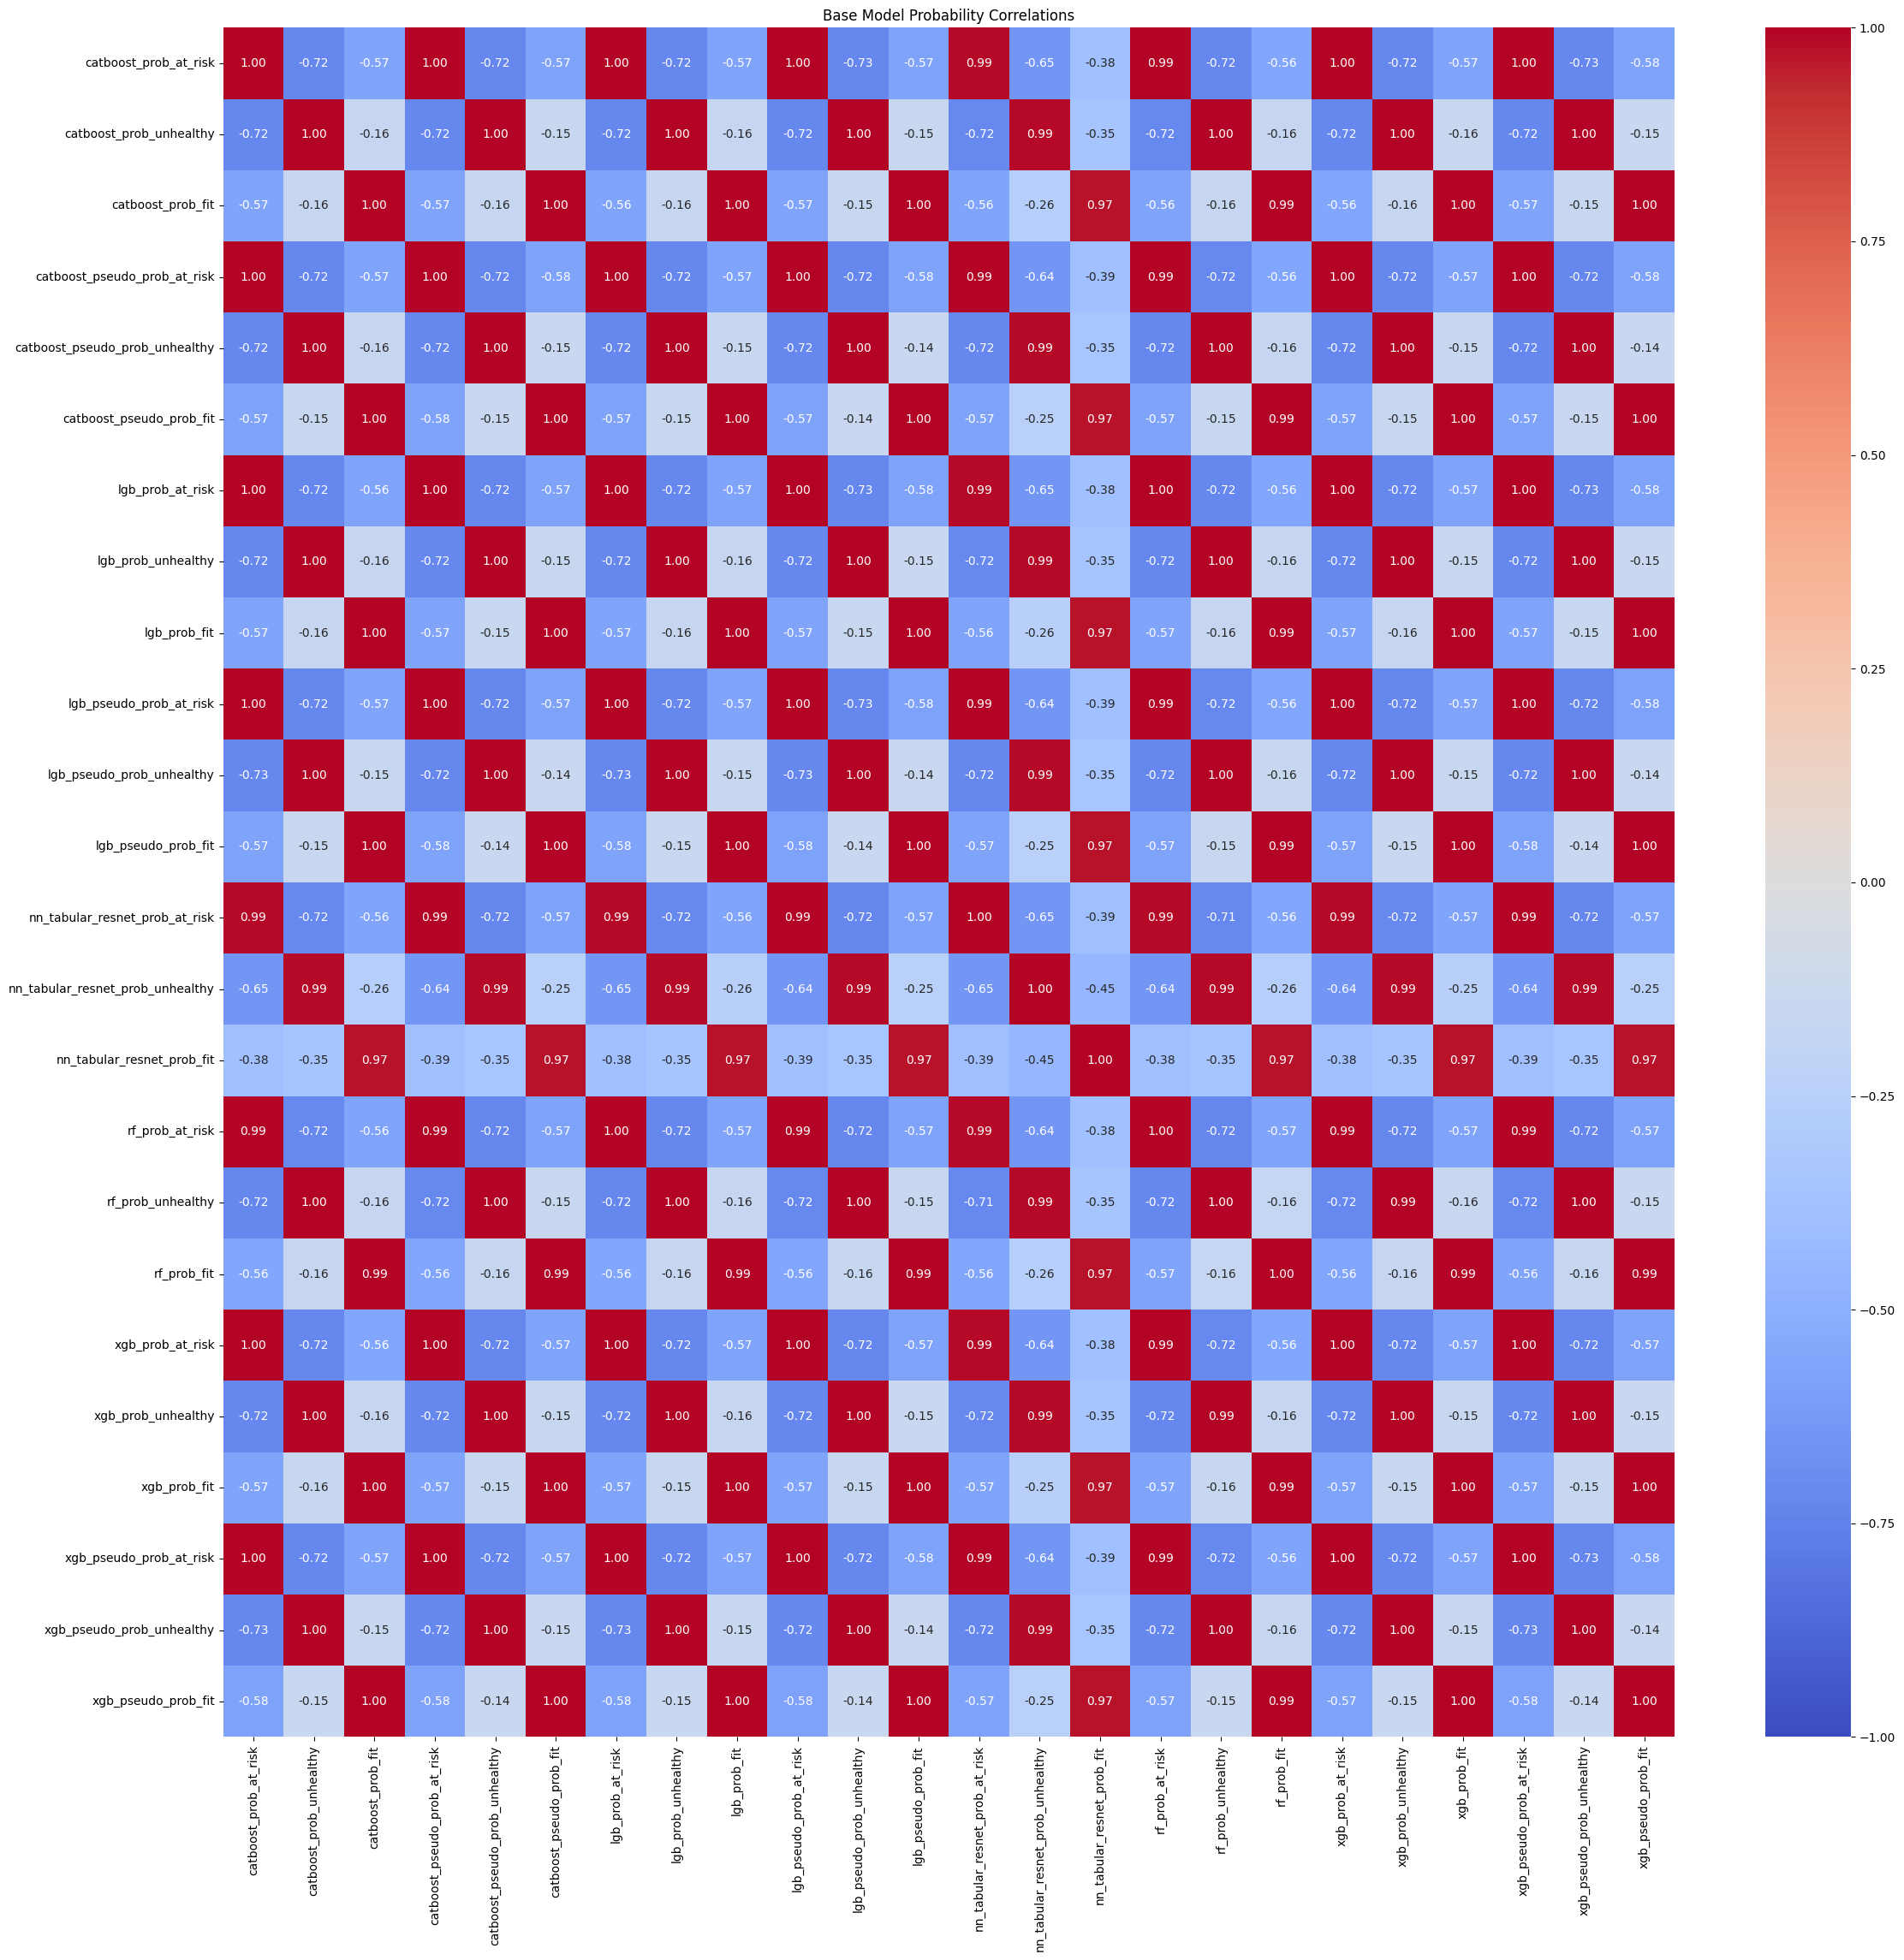

In [7]:
# Create DataFrames
oof_df = load_probs(oof_files)
test_df = load_probs(test_files)

# Report missing values in OOF data before dropping
raw_oof_len = len(oof_df)
missing_oof = oof_df.isna().sum().sort_values(ascending=False)
if missing_oof.any():
    print("Missing OOF values per column:")
    print(missing_oof[missing_oof > 0])

# Look for missing rows in test data
missing_by_model = test_df.isna().sum().sort_values(ascending=False)
print("Missing test rows per model:")
print(missing_by_model[missing_by_model > 0] if missing_by_model.any() else "None")

# Create an id-indexed label series
y_by_id = pd.Series(y_true.values, index=training_df['id'].values)

# Keep only rows where all models have OOF probabilities
oof_df = oof_df.sort_index().dropna(axis=0)
n_dropped = raw_oof_len - len(oof_df)
if n_dropped > 0:
    print(f"WARNING: Dropped {n_dropped} OOF rows with missing predictions across models.")
y_true_aligned = y_by_id.loc[oof_df.index].values

# Align test_df to submission id order — critical for correct label assignment
test_df = test_df.reindex(submission_df['id'].values)

# Restrict to columns present in both OOF and test (defensive against file mismatches)
common_cols = [c for c in oof_df.columns if c in test_df.columns]
if len(common_cols) < len(oof_df.columns):
    dropped_cols = set(oof_df.columns) - set(common_cols)
    print(f"WARNING: Dropping {len(dropped_cols)} columns not present in test_df: {dropped_cols}")
oof_df  = oof_df[common_cols]
test_df = test_df[common_cols]

print(f'\nOOF Shape: {oof_df.shape}')
print(f'Test Shape: {test_df.shape}')

# Probability correlation heatmap across all class columns
n_cols = len(oof_df.columns)
fig_size = max(10, n_cols)
plt.figure(figsize=(fig_size, fig_size - 1))
sns.heatmap(oof_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Base Model Probability Correlations')
plt.tight_layout()
plt.show()


In [8]:
print('\nIndividual Model Balanced Accuracy (OOF):')
individual_scores = {}

# Sorted for deterministic ordering
model_names = sorted(set([c.split('_prob_')[0] for c in oof_df.columns]))

for model in model_names:
    cols = [f"{model}_prob_at_risk", f"{model}_prob_unhealthy", f"{model}_prob_fit"]
    preds = np.argmax(oof_df[cols].values, axis=1)
    score = balanced_accuracy_score(y_true_aligned, preds)
    individual_scores[model] = score
    print(f'{model:30}: {score:.6f}')

best_single_model = max(individual_scores, key=individual_scores.get)
print(f'\nBest single model: {best_single_model} ({individual_scores[best_single_model]:.6f})')



Individual Model Balanced Accuracy (OOF):
catboost                      : 0.949976
catboost_pseudo               : 0.949493
lgb                           : 0.949850


lgb_pseudo                    : 0.949439
nn_tabular_resnet             : 0.948498
rf                            : 0.949237
xgb                           : 0.949927


xgb_pseudo                    : 0.949472

Best single model: catboost (0.949976)


## Stacking Optimization: Logistic Regression Meta-Model

We train a second-level meta-model on the base models' **OOF probabilities**.

* **Features (X):** OOF probabilities from each base model.
* **Target (y):** true class label (0=at-risk, 1=unhealthy, 2=fit).
* 
We use **logistic regression with L2 regularization** as the meta-model. It is fast, stable under correlation, and outputs a valid probability in [0, 1].
The regularization strength is tuned via internal cross-validation.


In [9]:
# ==========================================
# STACKING STRATEGY (Meta-Model)
# ==========================================

print('Preparing stacking data...')

# model_cols already restricted to columns present in both oof_df and test_df
model_cols = list(oof_df.columns)
print('Stacking feature columns:', model_cols)

X_stack      = oof_df[model_cols].to_numpy(dtype=np.float64)
X_test_stack = test_df[model_cols].to_numpy(dtype=np.float64)
y_stack = y_true_aligned

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Use RidgeClassifierCV for a robust linear stacking model
from sklearn.linear_model import RidgeClassifierCV
from scipy.optimize import minimize

meta_model = RidgeClassifierCV(
    alphas=np.logspace(-3, 3, 10),
    class_weight='balanced',
    cv=cv,
    scoring='balanced_accuracy'
)

# Cross-val predict the decision function of Ridge Classifier
oof_meta_decision = cross_val_predict(
    meta_model, X_stack, y_stack,
    cv=cv,
    method='decision_function',
    n_jobs=-1
)
oof_meta_preds = np.argmax(oof_meta_decision, axis=1)
score_meta = balanced_accuracy_score(y_stack, oof_meta_preds)
print(f'Meta-model OOF Balanced Accuracy (Default): {score_meta:.6f}')

# Tune decision function biases to maximize Balanced Accuracy
def optimize_biases(decision_func, y):
    def objective(b):
        biases = np.array([0.0, b[0], b[1]])
        preds = np.argmax(decision_func + biases, axis=1)
        return -balanced_accuracy_score(y, preds)
    
    best_score = -np.inf
    best_biases = None
    start_points = [[0.0, 0.0], [0.1, 0.1], [-0.1, -0.1], [0.5, 0.5], [-0.5, -0.5]]
    for start in start_points:
        res = minimize(objective, start, method='Nelder-Mead', options={'maxiter': 200})
        score = -res.fun
        if score > best_score:
            best_score = score
            best_biases = [0.0, res.x[0], res.x[1]]
    return best_score, best_biases

opt_stack_score, opt_stack_biases = optimize_biases(oof_meta_decision, y_stack)
print(f'Meta-model OOF Balanced Accuracy (Optimized): {opt_stack_score:.6f} (improvement: {opt_stack_score - score_meta:+.6f})')
print(f'Optimal Biases: {opt_stack_biases}')

# Final fit on ALL training data for test-set predictions
meta_model.fit(X_stack, y_stack)

# Convert OOF decision function to valid probabilities using softmax
exp_decision = np.exp(oof_meta_decision)
oof_meta_probs = exp_decision / np.sum(exp_decision, axis=1, keepdims=True)

# Save OOF meta-probabilities for higher-level ensembling
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)
prob_cols = ['prob_at_risk', 'prob_unhealthy', 'prob_fit']
oof_meta_df = pd.DataFrame(oof_meta_probs, columns=prob_cols, index=oof_df.index)
oof_meta_df.index.name = 'id'
oof_meta_df['target'] = y_stack
oof_meta_df = oof_meta_df.reset_index()[[ 'id', 'target'] + prob_cols]
oof_meta_df.to_csv(f'{output_dir}/stacking_oof_probs.csv', index=False)
print(f'Saved OOF meta-probabilities to {output_dir}/stacking_oof_probs.csv')

Preparing stacking data...
Stacking feature columns: ['catboost_prob_at_risk', 'catboost_prob_unhealthy', 'catboost_prob_fit', 'catboost_pseudo_prob_at_risk', 'catboost_pseudo_prob_unhealthy', 'catboost_pseudo_prob_fit', 'lgb_prob_at_risk', 'lgb_prob_unhealthy', 'lgb_prob_fit', 'lgb_pseudo_prob_at_risk', 'lgb_pseudo_prob_unhealthy', 'lgb_pseudo_prob_fit', 'nn_tabular_resnet_prob_at_risk', 'nn_tabular_resnet_prob_unhealthy', 'nn_tabular_resnet_prob_fit', 'rf_prob_at_risk', 'rf_prob_unhealthy', 'rf_prob_fit', 'xgb_prob_at_risk', 'xgb_prob_unhealthy', 'xgb_prob_fit', 'xgb_pseudo_prob_at_risk', 'xgb_pseudo_prob_unhealthy', 'xgb_pseudo_prob_fit']


Meta-model OOF Balanced Accuracy (Default): 0.950036


Meta-model OOF Balanced Accuracy (Optimized): 0.950128 (improvement: +0.000092)
Optimal Biases: [0.0, np.float64(0.05300787881715862), np.float64(0.4117816639714893)]


Saved OOF meta-probabilities to predictions/stacking_oof_probs.csv


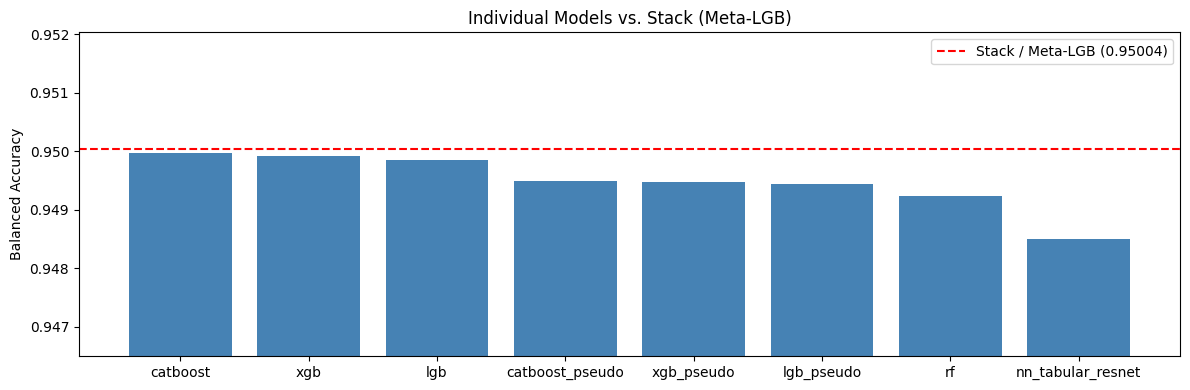

In [10]:
# Sort models by score descending for a cleaner chart
sorted_scores = dict(sorted(individual_scores.items(), key=lambda x: -x[1]))

plt.figure(figsize=(max(8, len(sorted_scores) * 1.5), 4))
bars = plt.bar(sorted_scores.keys(), sorted_scores.values(), color='steelblue')
plt.axhline(score_meta, color='red', linestyle='--',
            label=f'Stack / Meta-LGB ({score_meta:.5f})')
plt.ylabel('Balanced Accuracy')
y_min = min(min(sorted_scores.values()), score_meta) - 0.002
y_max = max(max(sorted_scores.values()), score_meta) + 0.002
plt.ylim(y_min, y_max)
plt.legend()
plt.title('Individual Models vs. Stack (Meta-LGB)')
plt.tight_layout()
plt.show()


## Final Ensemble & Submission

We generate test-set probabilities by applying the trained meta-model to the matrix of base-model test probabilities.
The submission file uses the competition's sample submission schema.


In [11]:
# Generate test predictions from the fitted meta-model
sub = submission_df.copy()
target_col = [c for c in sub.columns if c != 'id'][0]
reverse_mapping = {v: k for k, v in target_mapping.items()}

# Predict decision function on test set
test_meta_decision = meta_model.decision_function(X_test_stack)

# Apply optimized biases
test_meta_decision_tuned = test_meta_decision + np.array(opt_stack_biases)
test_meta_pred = np.argmax(test_meta_decision_tuned, axis=1)

# Assign directly
sub[target_col] = [reverse_mapping[p] for p in test_meta_pred]

sub.to_csv('submission.csv', index=False)
sub.to_csv('submission_stacking.csv', index=False)
sub.to_csv('submission_stacking_tuned.csv', index=False)
print('Saved: submission.csv, submission_stacking.csv, and submission_stacking_tuned.csv')

print('\nSUBMISSION')
print('==========')
print(sub.head(10))

print('\nPredicted Class Distribution:')
print(sub[target_col].value_counts(normalize=True).sort_index())

# Also save test meta-probabilities (using softmax on decision function) for higher-level ensembling
exp_test_decision = np.exp(test_meta_decision)
test_meta_probs = exp_test_decision / np.sum(exp_test_decision, axis=1, keepdims=True)

test_meta_df = pd.DataFrame(test_meta_probs, columns=prob_cols)
test_meta_df.insert(0, 'id', submission_df['id'].values)
test_meta_df.to_csv(f'{output_dir}/stacking_test_probs.csv', index=False)
print(f'Saved test meta-probabilities to {output_dir}/stacking_test_probs.csv')

Saved: submission.csv, submission_stacking.csv, and submission_stacking_tuned.csv

SUBMISSION
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
5  690093              fit
6  690094          at-risk
7  690095          at-risk
8  690096          at-risk
9  690097          at-risk

Predicted Class Distribution:
health_condition
at-risk     0.809
fit         0.074
unhealthy   0.116
Name: proportion, dtype: float64


Saved test meta-probabilities to predictions/stacking_test_probs.csv
